Tahap 1 : Data Scraping

In [22]:
!pip install google-play-scraper

from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

import datetime as dt
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
from google_play_scraper import Sort, reviews_all
import pandas as pd

scrapreview = reviews_all(
    'com.duolingo',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=10000
)

In [11]:
import csv

with open('ulasan_aplikasi.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Review'])
    for review in scrapreview:
        writer.writerow([review['content']])

In [12]:
df = pd.DataFrame(scrapreview)
df.shape

(246433, 11)

In [30]:
df.head()

,content,score,thumbsUpCount,reviewCreatedVersion,appVersion
0,sangat bagusss! hanya saja terkadang ada kesal...,4,1,6.74.5,6.74.5
1,Aplikasi Duolingo sangat bagus untuk belajar b...,5,1,6.74.5,6.74.5
2,Sekarang Aplikasi Duolingo Jelek. Keluar Sendi...,1,2,6.74.5,6.74.5
3,Aplikasinya bagus banget buat belajar bahasa I...,5,2,6.74.4,6.74.4
4,"terima kasih duolingo!!, ini sangat membantu s...",4,1,6.74.5,6.74.5


In [14]:
df = df.drop(columns=['reviewId', 'userName', 'userImage', 'at', 'replyContent', 'repliedAt'])

In [32]:
clean_df = df.dropna().copy()

clean_df = df.drop_duplicates().copy()

clean_df.shape

(218487, 5)

In [33]:
clean_df.head()

,content,score,thumbsUpCount,reviewCreatedVersion,appVersion
0,sangat bagusss! hanya saja terkadang ada kesal...,4,1,6.74.5,6.74.5
1,Aplikasi Duolingo sangat bagus untuk belajar b...,5,1,6.74.5,6.74.5
2,Sekarang Aplikasi Duolingo Jelek. Keluar Sendi...,1,2,6.74.5,6.74.5
3,Aplikasinya bagus banget buat belajar bahasa I...,5,2,6.74.4,6.74.4
4,"terima kasih duolingo!!, ini sangat membantu s...",4,1,6.74.5,6.74.5


Tahap 2 : Preprocessing Text

In [34]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text, language='english'): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text, language=language)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal"}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [36]:
clean_df['text_clean'] = clean_df['content'].fillna('').apply(cleaningText)

In [37]:
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

In [38]:
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

In [39]:
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

In [40]:
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

In [41]:
clean_df

,content,score,thumbsUpCount,reviewCreatedVersion,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword
0,sangat bagusss! hanya saja terkadang ada kesal...,4,1,6.74.5,6.74.5,sangat bagusss hanya saja terkadang ada kesala...,sangat bagusss hanya saja terkadang ada kesala...,sangat bagusss hanya saja terkadang ada kesala...,"[sangat, bagusss, hanya, saja, terkadang, ada,...","[bagusss, terkadang, kesalahan, terkadang, mem..."
1,Aplikasi Duolingo sangat bagus untuk belajar b...,5,1,6.74.5,6.74.5,Aplikasi Duolingo sangat bagus untuk belajar b...,aplikasi duolingo sangat bagus untuk belajar b...,aplikasi duolingo sangat bagus untuk belajar b...,"[aplikasi, duolingo, sangat, bagus, untuk, bel...","[aplikasi, duolingo, bagus, belajar, bahasa, s..."
2,Sekarang Aplikasi Duolingo Jelek. Keluar Sendi...,1,2,6.74.5,6.74.5,Sekarang Aplikasi Duolingo Jelek Keluar Sendir...,sekarang aplikasi duolingo jelek keluar sendir...,sekarang aplikasi duolingo jelek keluar sendir...,"[sekarang, aplikasi, duolingo, jelek, keluar, ...","[aplikasi, duolingo, jelek, belajar, xp, hangu..."
3,Aplikasinya bagus banget buat belajar bahasa I...,5,2,6.74.4,6.74.4,Aplikasinya bagus banget buat belajar bahasa I...,aplikasinya bagus banget buat belajar bahasa i...,aplikasinya bagus banget buat belajar bahasa i...,"[aplikasinya, bagus, banget, buat, belajar, ba...","[aplikasinya, bagus, banget, belajar, bahasa, ..."
4,"terima kasih duolingo!!, ini sangat membantu s...",4,1,6.74.5,6.74.5,terima kasih duolingo ini sangat membantu saya...,terima kasih duolingo ini sangat membantu saya...,terima kasih duolingo ini sangat membantu saya...,"[terima, kasih, duolingo, ini, sangat, membant...","[terima, kasih, duolingo, membantu, belajar, b..."
...,...,...,...,...,...,...,...,...,...,...
246424,🥀,1,0,None,None,,,,[],[]
246425,😡,1,0,None,None,,,,[],[]
246426,👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎,1,0,None,None,,,,[],[]
246427,🔥🔥,2,0,None,None,,,,[],[]


## Tahap 3 Melabeli Data Menjadi 3 Kelas (Positif, Negatif, Netral)

In [42]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [44]:
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score >= 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif

    # else:
    #     polarity = 'neutral'
    # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [47]:
def sentiment_analysis_3_classes(text):
    score = 0
    for word in text:
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
    for word in text:
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    if (score > 0):
        polarity = 'positive'
    elif (score < 0):
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

results = clean_df['text_stopword'].apply(sentiment_analysis_3_classes)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    86813
negative    79445
neutral     52229
Name: count, dtype: int64


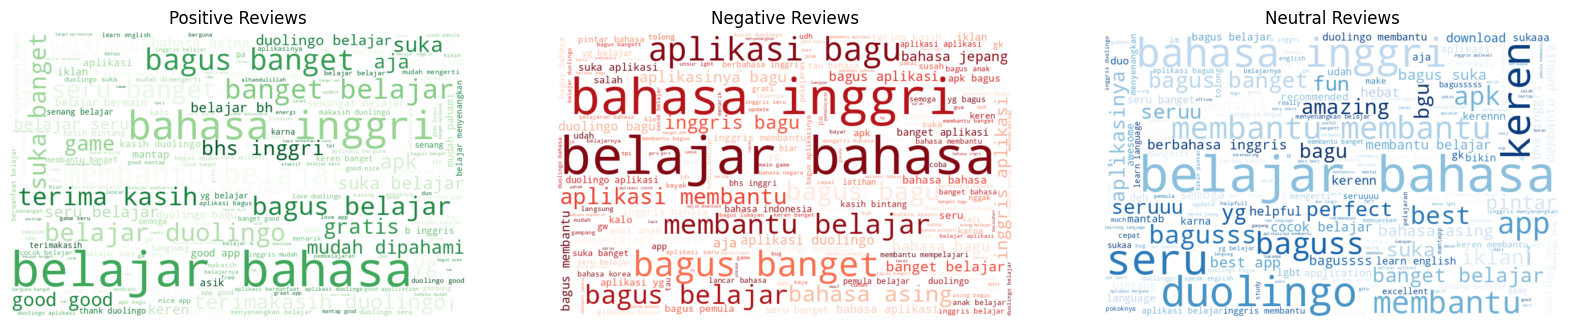

In [48]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Filter data berdasarkan polarity
df_pos = clean_df[clean_df['polarity'] == 'positive']
df_neg = clean_df[clean_df['polarity'] == 'negative']
df_neu = clean_df[clean_df['polarity'] == 'neutral']

# Gabungkan kata-kata menjadi string tunggal
all_words_pos = ' '.join([' '.join(tribute) for tribute in df_pos['text_stopword']])
all_words_neg = ' '.join([' '.join(tribute) for tribute in df_neg['text_stopword']])
all_words_neu = ' '.join([' '.join(tribute) for tribute in df_neu['text_stopword']])

# Buat visualisasi side-by-side
fig, axs = plt.subplots(1, 3, figsize=(20, 10))

# Word Cloud Positive
wordcloud_pos = WordCloud(width=800, height=500, background_color='white', colormap='Greens').generate(all_words_pos)
axs[0].imshow(wordcloud_pos, interpolation='bilinear')
axs[0].set_title('Positive Reviews')
axs[0].axis('off')

# Word Cloud Negative
wordcloud_neg = WordCloud(width=800, height=500, background_color='white', colormap='Reds').generate(all_words_neg)
axs[1].imshow(wordcloud_neg, interpolation='bilinear')
axs[1].set_title('Negative Reviews')
axs[1].axis('off')

# Word Cloud Neutral
wordcloud_neu = WordCloud(width=800, height=500, background_color='white', colormap='Blues').generate(all_words_neu)
axs[2].imshow(wordcloud_neu, interpolation='bilinear')
axs[2].set_title('Neutral Reviews')
axs[2].axis('off')

plt.show()

##Tahap 4 part 1 (Ekstraksi Fitur : TF-IDF, Pelatihan : Random Forest, dan Pembagian Data : 80/20)

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Menggabungkan token menjadi string kalimat untuk kolom text_akhir
clean_df['text_akhir'] = clean_df['text_stopword'].apply(lambda x: ' '.join(x))

X = clean_df['text_akhir']
y = clean_df['polarity']

# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8)
X_tfidf = tfidf.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

features_df.head()

,aja,amazing,anak,apapun,apk,aplikasi,aplikasinya,app,application,apps,...,tolong,tp,tpi,udah,udh,ulang,unsur,update,wajib,yg
0,0.0,0.0,0.0,0.0,0.0,0.168852,0.000000,0.0,0.0,0.0,...,0.283388,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.145278,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.399951,0.000000,0.0,0.0,0.0,...,0.335623,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.182853,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.409685,0.0,0.000000,0.0,0.0,0.0,0.168216
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.572989,0.0,0.0,0.0,0.000000


In [53]:
from sklearn.ensemble import RandomForestClassifier

# Membuat objek model Random Forest
random_forest = RandomForestClassifier()

# Melatih model Random Forest pada data pelatihan
random_forest.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

# Menampilkan akurasi
print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9460492365080182
Random Forest - accuracy_test: 0.8844798388942285


### Tahap 4 part 2 (Ekstraksi Fitur: N-Gram, Pelatihan: Naive Bayes, dan Pembagian Data : 80/20)

In [64]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Ekstraksi Fitur dengan N-Gram (Unigram + Bigram + Trigram + 4-gram)
ngram_vectorizer = CountVectorizer(ngram_range=(1, 4), max_features=2000)
X_ngram = ngram_vectorizer.fit_transform(clean_df['text_akhir'])
y_ngram = clean_df['polarity']

# 2. Bagi Data 80/20
X_train_ngram, X_test_ngram, y_train_ngram, y_test_ngram = train_test_split(X_ngram, y_ngram, test_size=0.2, random_state=42)

# 3. Pelatihan Naive Bayes
nb_ngram_model = MultinomialNB()
nb_ngram_model.fit(X_train_ngram, y_train_ngram)

# 4. Prediksi untuk Data Training dan Test
y_pred_train_ngram = nb_ngram_model.predict(X_train_ngram)
y_pred_test_ngram = nb_ngram_model.predict(X_test_ngram)

# 5. Evaluasi Hasil
accuracy_train_ngram = accuracy_score(y_train_ngram, y_pred_train_ngram)
accuracy_test_ngram = accuracy_score(y_test_ngram, y_pred_test_ngram)

print(f"Naive Bayes (N-Gram) - Akurasi Training: {accuracy_train_ngram * 100:.2f}%")
print(f"Naive Bayes (N-Gram) - Akurasi Testing: {accuracy_test_ngram * 100:.2f}%")

Naive Bayes (N-Gram) - Akurasi Training: 77.22%
Naive Bayes (N-Gram) - Akurasi Testing: 76.81%


## Tahap 4 Part 3 (Ekstraksi Fitur : BoW, Pelatihan : Logistic Regression, Pembagian Data : 80/20)

Akurasi Training: 95.80%
Akurasi Testing: 95.08%

Classification Report (Data Testing):
              precision    recall  f1-score   support

    negative       0.96      0.96      0.96     15759
     neutral       0.93      0.91      0.92     10497
    positive       0.96      0.97      0.96     17442

    accuracy                           0.95     43698
   macro avg       0.95      0.95      0.95     43698
weighted avg       0.95      0.95      0.95     43698



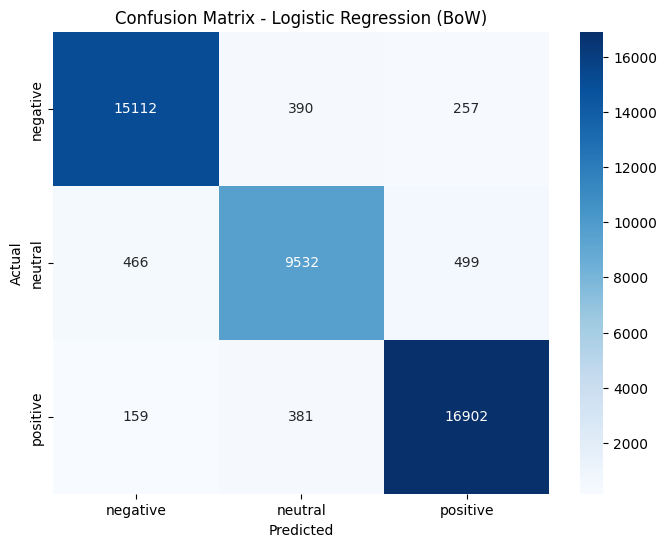

In [63]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ekstraksi Fitur dengan Bag of Words (BoW)
bow_vectorizer = CountVectorizer(max_features=2500)
X_bow = bow_vectorizer.fit_transform(clean_df['text_akhir'])
y_bow = clean_df['polarity']

# 2. Pembagian Data 80/20
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_bow, y_bow, test_size=0.2, random_state=42)

# 3. Pelatihan Model Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_lr, y_train_lr)

# 4. Prediksi untuk Data Training dan Test
y_pred_train_lr = lr_model.predict(X_train_lr)
y_pred_test_lr = lr_model.predict(X_test_lr)

# 5. Evaluasi Hasil
accuracy_train_lr = accuracy_score(y_train_lr, y_pred_train_lr)
accuracy_test_lr = accuracy_score(y_test_lr, y_pred_test_lr)

print(f'Akurasi Training: {accuracy_train_lr * 100:.2f}%')
print(f'Akurasi Testing: {accuracy_test_lr * 100:.2f}%\n')

print('Classification Report (Data Testing):')
print(classification_report(y_test_lr, y_pred_test_lr))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test_lr, y_pred_test_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_)
plt.title('Confusion Matrix - Logistic Regression (BoW)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Tahap 4 Part 4 (Pelatihan Model : Deep Learning - LSTM)

In [65]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

# 1. Menyiapkan Data
X_dl = clean_df['text_akhir'].values
y_dl = clean_df['polarity'].values

# Encode label (positive, negative, neutral) menjadi angka
le = LabelEncoder()
y_encoded = le.fit_transform(y_dl)
y_onehot = tf.keras.utils.to_categorical(y_encoded)

# 2. Tokenisasi dan Padding
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_dl)
sequences = tokenizer.texts_to_sequences(X_dl)
X_padded = pad_sequences(sequences, maxlen=max_len)

# 3. Pembagian Data 80/20
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_padded, y_onehot, test_size=0.2, random_state=42)

# 4. Membangun Arsitektur Model LSTM
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_words, 128, input_length=max_len),
    tf.keras.layers.SpatialDropout1D(0.2),
    tf.keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [66]:
# 5. Pelatihan Model
# Menggunakan epochs kecil (misal: 5) agar proses tidak terlalu lama di Colab
history = model.fit(X_train_dl, y_train_dl, epochs=5, batch_size=64,
                    validation_data=(X_test_dl, y_test_dl), verbose=1)

# 6. Evaluasi Akhir
loss, accuracy = model.evaluate(X_test_dl, y_test_dl)
print(f'\nDeep Learning (LSTM) - Akurasi Testing: {accuracy * 100:.2f}%')

Epoch 1/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 475s 172ms/step - accuracy: 0.9282 - loss: 0.2042 - val_accuracy: 0.9647 - val_loss: 0.1150
Epoch 2/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 497s 171ms/step - accuracy: 0.9726 - loss: 0.0907 - val_accuracy: 0.9770 - val_loss: 0.0855
Epoch 3/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 473s 173ms/step - accuracy: 0.9796 - loss: 0.0710 - val_accuracy: 0.9787 - val_loss: 0.0809
Epoch 4/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 466s 171ms/step - accuracy: 0.9836 - loss: 0.0602 - val_accuracy: 0.9815 - val_loss: 0.0765
Epoch 5/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 469s 172ms/step - accuracy: 0.9851 - loss: 0.0539 - val_accuracy: 0.9814 - val_loss: 0.0769
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.9814 - loss: 0.0769

Deep Learning (LSTM) - Akurasi Testing: 98.14%
